# 03 — Temperature Scaling of the Risk-Band Softmax

**FusionCore v2 — Phase Ph-v2.2**

Temperature scaling (Guo *et al.* 2017) is the simplest neural-network
calibration method: replace $\sigma(\mathbf{z})_i$ with
$\sigma(\mathbf{z}/T)_i$ for a single scalar $T > 0$. The temperature is
chosen by minimising the negative log-likelihood on a held-out calibration
set:

$$T^* = \arg\min_{T > 0} \;\; -\frac{1}{N}\sum_{i=1}^{N} \log \sigma(\mathbf{z}_i / T)_{y_i}$$

$T = 1$ is the identity. $T > 1$ smooths over-confident predictions; $T < 1$
sharpens under-confident ones. Crucially, **temperature scaling preserves the
arg-max** — it leaves the predicted class unchanged but adjusts the
probabilities. This means the headline F₂ / recall on Ph-v2.3 is unaffected
by Ph-v2.2; only the *probabilistic* metrics (NLL, ECE, Brier) move.

### Calibration set

The same 50 / 50 split of v1 Internal Validation as in Ph-v2.1 — the
calibration slice is shared. RNG = 42 ensures reproducibility. The
evaluation slice is used for a sanity check that the fitted T also reduces
ECE on data not used for fitting.

### Outputs

| File | Purpose |
|---|---|
| `phase_v2_2_temperature.pkl` | Scalar T |
| `phase_v2_2_calibration_metadata.json` | Pre/post ECE on cal & eval slices, per-class reliability bins |
| `phase_v2_2_reliability_diagram.png` | Pre vs post reliability curves with diagonal reference |

### References
- Guo, C., Pleiss, G., Sun, Y. and Weinberger, K. Q. (2017). On calibration of modern neural networks. *ICML 2017*.
- Naeini, M. P., Cooper, G. F. and Hauskrecht, M. (2015). Obtaining well-calibrated probabilities. *AAAI 2015*.

## Cell 1 — Imports

In [1]:
# ============================================================================
# Cell 1 — Imports
# ============================================================================
import sys, os, json, warnings, time, math
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib as mpl
warnings.filterwarnings("ignore")
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")

Python  : 3.13.13
PyTorch : 2.11.0


## Cell 2 — Palette

In [2]:
# ============================================================================
# Cell 2 — Palette
# ============================================================================
FC_DARK_BLUE  = "#0D1B2A"; FC_NAVY = "#1B3A5C"; FC_ORANGE = "#D96A1B"
FC_DEEP_RED   = "#9B1B30"; FC_STEEL = "#4A6274"; FC_CHARCOAL = "#2D2D2D"
FC_LIGHT_GREY = "#E8E8E8"
FC_PALETTE = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED, FC_STEEL, FC_NAVY]
plt.rcParams.update({
    "figure.figsize":(14,5), "figure.dpi":110, "savefig.dpi":300, "savefig.bbox":"tight",
    "font.family":"serif", "font.size":11,
    "axes.titlesize":13, "axes.titleweight":"bold", "axes.labelsize":11,
    "axes.edgecolor":FC_CHARCOAL, "axes.labelcolor":FC_CHARCOAL,
    "axes.spines.top":False, "axes.spines.right":False,
    "axes.prop_cycle":mpl.cycler(color=FC_PALETTE),
    "xtick.color":FC_CHARCOAL, "ytick.color":FC_CHARCOAL,
    "legend.fontsize":9, "legend.framealpha":0.9,
    "grid.color":FC_LIGHT_GREY, "grid.alpha":0.6, "grid.linestyle":":",
})
print("Palette configured.")

Palette configured.


In [3]:
# ============================================================================
# Cell 3 — Constants and Paths
# ============================================================================
PROJECT_ROOT = Path("/Users/michelemaestrini/Desktop/PiNet/FusionCore")
V1_OUT = PROJECT_ROOT / "v1" / "outputs"
V2_OUT = PROJECT_ROOT / "v2" / "outputs"

W = 30; N_FEATURES = 89; N_PHYSICS_TOKENS = 11
TCN_HIDDEN = 64; TCN_KERNEL = 3; TCN_DILATIONS = [1,2,4,8,16]; TCN_DROPOUT = 0.25
EMBED_DIM = 128; PHYS_HIDDEN = 50; PHYS_OUT = 32; HEAD_HIDDEN = 64
N_RISK_CLASSES = 3; RUL_CAP = 125; BATCH_SIZE = 64

CALIBRATION_FRACTION = 0.50
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print(f"Device : {DEVICE}")

Device : mps


---

## Part A — PiNet (re-defined inline) and Load Best Checkpoint

In [4]:
# ============================================================================
# Cell 4 — PiNet Architecture
# ============================================================================
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.left_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=0, dilation=dilation)
    def forward(self, x): return self.conv(F.pad(x, (self.left_pad, 0)))
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.norm1 = nn.LayerNorm(out_ch)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.norm2 = nn.LayerNorm(out_ch)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x)
        h = self.conv1(x); h = self.norm1(h.transpose(1,2)).transpose(1,2)
        h = F.relu(h); h = self.dropout(h)
        h = self.conv2(h); h = self.norm2(h.transpose(1,2)).transpose(1,2)
        h = h + residual; h = F.relu(h); h = self.dropout(h)
        return h
class TCN(nn.Module):
    def __init__(self):
        super().__init__()
        layers, ic = [], N_FEATURES
        for d in TCN_DILATIONS:
            layers.append(TemporalBlock(ic, TCN_HIDDEN, TCN_KERNEL, d, TCN_DROPOUT))
            ic = TCN_HIDDEN
        self.network = nn.Sequential(*layers)
    def forward(self, x): return self.network(x.transpose(1,2)).transpose(1,2)
class PhysicsMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_PHYSICS_TOKENS, PHYS_HIDDEN), nn.BatchNorm1d(PHYS_HIDDEN), nn.ReLU(),
            nn.Linear(PHYS_HIDDEN, PHYS_OUT), nn.BatchNorm1d(PHYS_OUT), nn.ReLU(),
        )
    def forward(self, x_phys, regime_w):
        return self.net(torch.cat([x_phys[:, -1, :], regime_w.unsqueeze(-1)], dim=-1))
class FusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        ind = TCN_HIDDEN*2 + PHYS_OUT
        h = (ind + EMBED_DIM)//2
        self.net = nn.Sequential(
            nn.Linear(ind, h), nn.LayerNorm(h), nn.ReLU(),
            nn.Linear(h, EMBED_DIM), nn.LayerNorm(EMBED_DIM), nn.ReLU(),
        )
    def forward(self, x): return self.net(x)
class RULHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, 1))
    def forward(self, x): return self.net(x).squeeze(-1)
class RiskBandHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, N_RISK_CLASSES))
    def forward(self, x): return self.net(x)
class PiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn=TCN(); self.physics=PhysicsMLP(); self.fusion=FusionMLP()
        self.rul_head=RULHead(); self.risk_head=RiskBandHead()
    @staticmethod
    def _masked_mean(h, mask):
        m = mask.float().unsqueeze(-1)
        return (h*m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)
    def forward(self, x_tcn, x_phys, mask, regime_w):
        h        = self.tcn(x_tcn)
        last_h   = h[:, -1, :]
        mean_h   = self._masked_mean(h, mask)
        tcn_out  = torch.cat([last_h, mean_h], dim=-1)
        phys_out = self.physics(x_phys, regime_w)
        embed    = self.fusion(torch.cat([tcn_out, phys_out], dim=-1))
        return {"rul_pred":self.rul_head(embed),
                "risk_logits":self.risk_head(embed),
                "embed":embed}
print("PiNet defined.")

PiNet defined.


In [5]:
# ============================================================================
# Cell 5 — Load Best Checkpoint
# ============================================================================
stage_b = V2_OUT / "phase_v2_0_pinet_stage_b_best.pt"
stage_a = V1_OUT / "phase_v1_3_pinet_best.pt"
init_p  = V1_OUT / "phase_v1_2_pinet_init.pt"
pinet = PiNet().to(DEVICE)
SMOKE_MODE = False
if stage_b.exists():
    state = torch.load(stage_b, map_location=DEVICE, weights_only=True)
    provenance = "v2 Stage B"
elif stage_a.exists():
    state = torch.load(stage_a, map_location=DEVICE, weights_only=True)
    provenance = "v1 Stage A (FALLBACK)"; SMOKE_MODE = True
else:
    state = torch.load(init_p, map_location=DEVICE, weights_only=True)
    provenance = "v1.2 init (SMOKE)"; SMOKE_MODE = True
pinet.load_state_dict(state); pinet.eval()
print(f"PiNet loaded: {provenance}")

PiNet loaded: v2 Stage B


---

## Part B — Reproduce the 50/50 Split and Extract Logits

In [6]:
# ============================================================================
# Cell 6 — Build the Same 50/50 Split as Ph-v2.1
# ============================================================================
val_bundle = torch.load(V1_OUT / "windows_val.pt", weights_only=False)
Xw_val = val_bundle["Xw"]; mask_val = val_bundle["mask"]
rul_val = val_bundle["rul"]; rb_val = val_bundle["risk_band"]
rw_val = val_bundle["regime_w"]
phys_idx = torch.load(V1_OUT / "windows_train.pt", weights_only=False)["phys_idx"]

n_val = len(rul_val)
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(n_val)
n_cal = int(round(CALIBRATION_FRACTION * n_val))
cal_idx  = np.sort(perm[:n_cal])
eval_idx = np.sort(perm[n_cal:])
print(f"Calibration : {len(cal_idx):,}    Evaluation : {len(eval_idx):,}")

Calibration : 15,514    Evaluation : 15,514


In [7]:
# ============================================================================
# Cell 7 — Extract Logits and Labels
# ============================================================================
class _DS(Dataset):
    def __init__(s, Xw, mk, rul, rb, rw, pi, idx):
        s.Xw, s.mk, s.rul, s.rb, s.rw, s.pi = Xw, mk, rul, rb, rw, pi
        s.idx = torch.from_numpy(np.asarray(idx, dtype=np.int64))
    def __len__(s): return len(s.idx)
    def __getitem__(s, i):
        j = int(s.idx[i]); x = s.Xw[j]
        return {"x_tcn":x, "x_phys":x.index_select(-1, s.pi),
                "mask":s.mk[j], "rul":s.rul[j], "risk_band":s.rb[j], "regime_w":s.rw[j]}

ds_cal  = _DS(Xw_val, mask_val, rul_val, rb_val, rw_val, phys_idx, cal_idx)
ds_eval = _DS(Xw_val, mask_val, rul_val, rb_val, rw_val, phys_idx, eval_idx)
dl_cal  = DataLoader(ds_cal,  batch_size=BATCH_SIZE, shuffle=False)
dl_eval = DataLoader(ds_eval, batch_size=BATCH_SIZE, shuffle=False)

@torch.no_grad()
def extract_logits(model, loader):
    model.eval()
    L_a, y_a = [], []
    for batch in loader:
        bd = {k:v.to(DEVICE, non_blocking=True) for k,v in batch.items()}
        out = model(bd["x_tcn"], bd["x_phys"], bd["mask"], bd["regime_w"])
        L_a.append(out["risk_logits"].cpu().numpy())
        y_a.append(bd["risk_band"].cpu().numpy())
    return np.concatenate(L_a), np.concatenate(y_a)

t0 = time.time()
logits_cal,  labels_cal  = extract_logits(pinet, dl_cal)
logits_eval, labels_eval = extract_logits(pinet, dl_eval)
print(f"Cal logits  : {logits_cal.shape}    labels : {labels_cal.shape}")
print(f"Eval logits : {logits_eval.shape}   labels : {labels_eval.shape}    ({time.time()-t0:.1f}s)")

Cal logits  : (15514, 3)    labels : (15514,)
Eval logits : (15514, 3)   labels : (15514,)    (1.6s)


---

## Part C — Optimise Temperature via L-BFGS on Calibration NLL

In [8]:
# ============================================================================
# Cell 8 — Fit T by Minimising NLL on Calibration Logits
# ============================================================================
logits_t = torch.from_numpy(logits_cal).float().to(DEVICE)
labels_t = torch.from_numpy(labels_cal).long().to(DEVICE)

T = nn.Parameter(torch.ones(1, device=DEVICE))
optimiser = torch.optim.LBFGS([T], lr=0.01, max_iter=200, line_search_fn="strong_wolfe")

def closure():
    optimiser.zero_grad()
    nll = F.cross_entropy(logits_t / T.clamp(min=1e-3), labels_t)
    nll.backward()
    return nll

optimiser.step(closure)
T_value = float(T.detach().cpu().item())
print(f"Fitted temperature : T = {T_value:.4f}")
joblib.dump(T_value, V2_OUT / "phase_v2_2_temperature.pkl")
print(f"Saved {V2_OUT / 'phase_v2_2_temperature.pkl'}")

Fitted temperature : T = 1.2298
Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_2_temperature.pkl


---

## Part D — Pre/Post ECE and Reliability Diagram

In [9]:
# ============================================================================
# Cell 9 — Expected Calibration Error
# ============================================================================
def softmax_np(z, T=1.0):
    z = z / T
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def ece(probs, labels, n_bins=15):
    """Naeini et al. 2015 — equal-width bin ECE on top-1 confidence."""
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece_val = 0.0
    n = len(labels)
    bin_stats = []
    for i in range(n_bins):
        m = (conf > bins[i]) & (conf <= bins[i+1])
        if m.sum() == 0:
            bin_stats.append((bins[i], bins[i+1], 0, np.nan, np.nan))
            continue
        acc = correct[m].mean()
        avg_conf = conf[m].mean()
        weight = m.sum() / n
        ece_val += weight * abs(acc - avg_conf)
        bin_stats.append((bins[i], bins[i+1], int(m.sum()), float(acc), float(avg_conf)))
    return float(ece_val), bin_stats

probs_cal_pre  = softmax_np(logits_cal, T=1.0)
probs_cal_post = softmax_np(logits_cal, T=T_value)
probs_ev_pre   = softmax_np(logits_eval, T=1.0)
probs_ev_post  = softmax_np(logits_eval, T=T_value)

ece_cal_pre,  bins_cal_pre  = ece(probs_cal_pre,  labels_cal)
ece_cal_post, bins_cal_post = ece(probs_cal_post, labels_cal)
ece_ev_pre,   bins_ev_pre   = ece(probs_ev_pre,   labels_eval)
ece_ev_post,  bins_ev_post  = ece(probs_ev_post,  labels_eval)

print(f"{'set':<14} {'pre-T ECE':>10} {'post-T ECE':>11} {'Δ':>10}")
print(f"{'calibration':<14} {ece_cal_pre:>10.4f} {ece_cal_post:>11.4f} {ece_cal_post-ece_cal_pre:>+10.4f}")
print(f"{'evaluation':<14} {ece_ev_pre:>10.4f} {ece_ev_post:>11.4f} {ece_ev_post-ece_ev_pre:>+10.4f}")

set             pre-T ECE  post-T ECE          Δ
calibration        0.0234      0.0068    -0.0166
evaluation         0.0269      0.0105    -0.0164


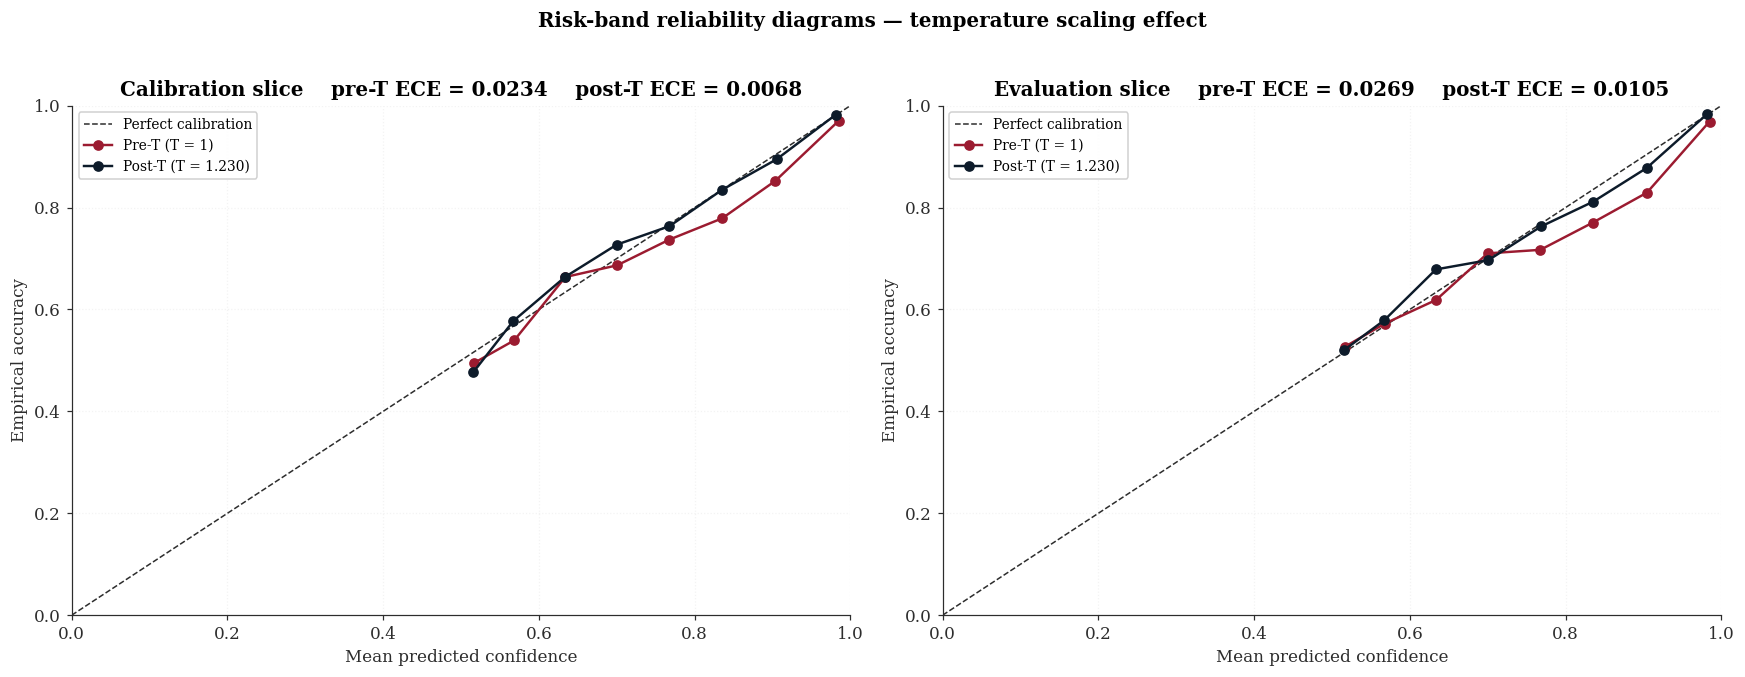

In [10]:
# ============================================================================
# Cell 10 — Visual: Reliability Diagram (pre vs post)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, bins_pre, bins_post, name in [(axes[0], bins_cal_pre, bins_cal_post, "Calibration slice"),
                                       (axes[1], bins_ev_pre,  bins_ev_post,  "Evaluation slice")]:
    centres_pre  = [(b[0]+b[1])/2 for b in bins_pre  if b[2] > 0]
    accs_pre     = [b[3] for b in bins_pre  if b[2] > 0]
    confs_pre    = [b[4] for b in bins_pre  if b[2] > 0]
    centres_post = [(b[0]+b[1])/2 for b in bins_post if b[2] > 0]
    accs_post    = [b[3] for b in bins_post if b[2] > 0]
    confs_post   = [b[4] for b in bins_post if b[2] > 0]

    ax.plot([0,1], [0,1], color=FC_CHARCOAL, linewidth=1.0, linestyle="--", label="Perfect calibration")
    ax.plot(confs_pre,  accs_pre,  color=FC_DEEP_RED,  linewidth=1.6, marker="o", label="Pre-T (T = 1)")
    ax.plot(confs_post, accs_post, color=FC_DARK_BLUE, linewidth=1.6, marker="o", label=f"Post-T (T = {T_value:.3f})")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted confidence")
    ax.set_ylabel("Empirical accuracy")
    ax.set_title(f"{name}    pre-T ECE = "
                 + (f"{ece_cal_pre:.4f}" if "Cal" in name else f"{ece_ev_pre:.4f}")
                 + f"    post-T ECE = "
                 + (f"{ece_cal_post:.4f}" if "Cal" in name else f"{ece_ev_post:.4f}"))
    ax.legend(); ax.grid(linestyle=":", alpha=0.5)
plt.suptitle("Risk-band reliability diagrams — temperature scaling effect",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(V2_OUT / "phase_v2_2_reliability_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# ============================================================================
# Cell 11 — Persist Calibration Metadata
# ============================================================================
meta = {
    "smoke_mode":          SMOKE_MODE,
    "pinet_provenance":    provenance,
    "temperature":         T_value,
    "ece_calibration_pre": ece_cal_pre,
    "ece_calibration_post":ece_cal_post,
    "ece_evaluation_pre":  ece_ev_pre,
    "ece_evaluation_post": ece_ev_post,
    "n_calibration":       int(len(cal_idx)),
    "n_evaluation":        int(len(eval_idx)),
    "n_bins":              15,
    "calibration_bins": [{"lo":b[0],"hi":b[1],"n":b[2],"acc":b[3],"conf":b[4]}
                          for b in bins_cal_post if not (np.isnan(b[3]) and np.isnan(b[4]))],
    "evaluation_bins":  [{"lo":b[0],"hi":b[1],"n":b[2],"acc":b[3],"conf":b[4]}
                          for b in bins_ev_post if not (np.isnan(b[3]) and np.isnan(b[4]))],
}
with open(V2_OUT / "phase_v2_2_calibration_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"Saved {V2_OUT / 'phase_v2_2_calibration_metadata.json'}")

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v2/outputs/phase_v2_2_calibration_metadata.json


---

## Ph-v2.2 Gate

In [12]:
# ============================================================================
# Cell 12 — Ph-v2.2 Gate
# ============================================================================
print("="*78); print("  Ph-v2.2 GATE — Temperature Scaling"); print("="*78)
checks = []
checks.append(("Temperature finite and positive",
               np.isfinite(T_value) and T_value > 0, f"T = {T_value:.4f}"))
checks.append(("Post-T calibration ECE not worse than pre-T (≤ pre + 1e-4)",
               ece_cal_post <= ece_cal_pre + 1e-4,
               f"pre = {ece_cal_pre:.4f} → post = {ece_cal_post:.4f}"))
checks.append(("Post-T evaluation ECE not significantly worse than pre-T (≤ +0.01)",
               ece_ev_post <= ece_ev_pre + 0.01,
               f"pre = {ece_ev_pre:.4f} → post = {ece_ev_post:.4f}"))
checks.append(("Persisted: phase_v2_2_temperature.pkl",
               (V2_OUT / "phase_v2_2_temperature.pkl").exists(), "OK"))
checks.append(("Persisted: phase_v2_2_calibration_metadata.json",
               (V2_OUT / "phase_v2_2_calibration_metadata.json").exists(), "OK"))
checks.append(("Persisted: phase_v2_2_reliability_diagram.png",
               (V2_OUT / "phase_v2_2_reliability_diagram.png").exists(), "OK"))

# Round-trip.
try:
    T_loaded = joblib.load(V2_OUT / "phase_v2_2_temperature.pkl")
    rt_ok = (abs(T_loaded - T_value) < 1e-9)
except Exception:
    rt_ok = False
checks.append(("Temperature artefact round-trips", rt_ok, "OK"))

for desc, ok, detail in checks:
    flag = "PASS" if ok else "FAIL"
    print(f"  [{flag}] {desc:<60s} {detail}")
n_pass = sum(1 for _,o,_ in checks if o)
print(f"\n  Ph-v2.2 GATE: {n_pass}/{len(checks)} PASS")
if not all(o for _,o,_ in checks):
    fails = [d for d, o, _ in checks if not o]
    print(f"\n  FAILING checks ({len(fails)}):")
    for f in fails:
        print(f"    - {f}")
assert all(o for _,o,_ in checks), "Ph-v2.2 GATE FAILED"
if SMOKE_MODE:
    print("  SMOKE MODE — re-run after Stage B (Ph-v2.0).")
print("  Ph-v2.2 — proceed to Ph-v2.3 (headline evaluation)")

  Ph-v2.2 GATE — Temperature Scaling
  [PASS] Temperature finite and positive                              T = 1.2298
  [PASS] Post-T calibration ECE not worse than pre-T (≤ pre + 1e-4)   pre = 0.0234 → post = 0.0068
  [PASS] Post-T evaluation ECE not significantly worse than pre-T (≤ +0.01) pre = 0.0269 → post = 0.0105
  [PASS] Persisted: phase_v2_2_temperature.pkl                        OK
  [PASS] Persisted: phase_v2_2_calibration_metadata.json              OK
  [PASS] Persisted: phase_v2_2_reliability_diagram.png                OK
  [PASS] Temperature artefact round-trips                             OK

  Ph-v2.2 GATE: 7/7 PASS
  Ph-v2.2 — proceed to Ph-v2.3 (headline evaluation)


---

## Summary

### Ph-v2.2 outputs
- `phase_v2_2_temperature.pkl` — scalar T
- `phase_v2_2_calibration_metadata.json`
- `phase_v2_2_reliability_diagram.png`

### Note on what temperature scaling does NOT change
- The argmax — predicted class is identical pre and post
- F₂, recall, precision (these depend only on argmax)
- RUL predictions

### What temperature scaling DOES change
- Predicted probabilities and entropy
- NLL, ECE, Brier scores
- Confidence available to the operations dashboard

### Next notebook
`04_Headline_Evaluation.ipynb` — Stage B + conformal + temperature on the NASA test set.